In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.shape
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

Data Preprocessing

In [5]:
#Handle missing value
df["Income"] = df["Income"].fillna(df["Income"].median())

In [6]:
#df.isnull().sum()
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


Feature Engineering

In [7]:
#Feature Engineering
#Age
df["Age"] = 2026-df["Year_Birth"]

In [8]:
#Customer joining date in days 
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)

reference_data = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_data - df["Dt_Customer"]).dt.days

In [9]:
#Total spending on this smartcart
df["Total_spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

#Total children number 
df["Total_children"] = df["Kidhome"] + df["Teenhome"]

In [40]:
#Education
df["Education"].value_counts() #now convert thwm in simple 3 categories only instead of 5
#Undergraduate(2n cycle,Basic), Graduation, Postgraduate(phD,Master)
df["Education"] = df["Education"].replace({
    "Basic":"Undergraduate", "2n Cycle":"Undergraduate",
    "Graduation":"Graduate",
    "Master":"Postgraduate", "PhD":"Postgraduate" 
})

#Maritial status
df["Living_With"] = df["Marital_Status"].replace({
    "Married":"Partner", "Together":"Partner",
    "Single":"Alone", "Divorced":"Alone",
    "Widow":"Alone", "YOLO":"Alone","Absurd":"Alone" 
})

In [41]:
df["Education"].value_counts()
df["Living_With"].value_counts()


Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

Drop columns 

In [42]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


In [43]:
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols = ["MntWines" ,"MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns = cols_to_drop)

In [44]:
df_cleaned.shape

(2240, 15)

Outliers 

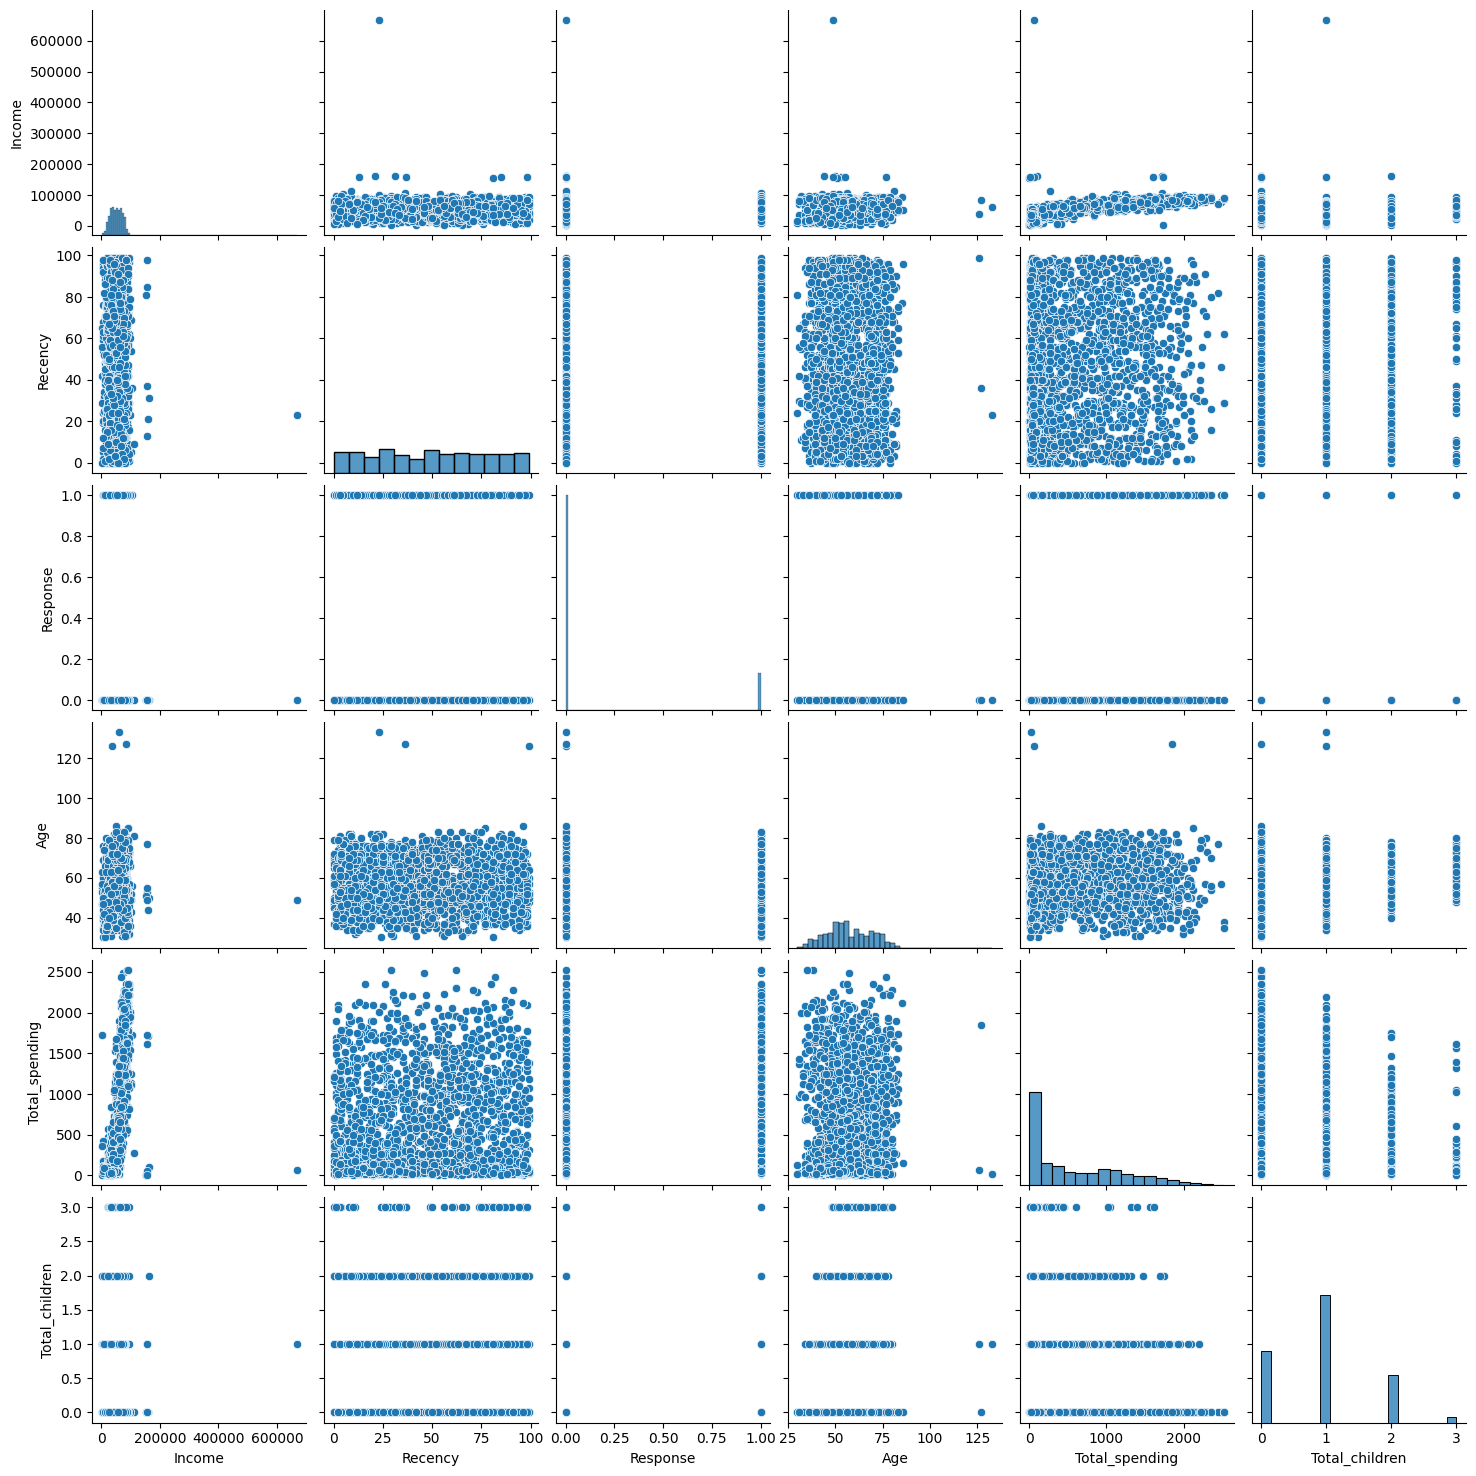

In [45]:
cols =  ["Income","Recency","Response","Age","Total_spending","Total_children"]

#Relative plots of some features -  pair plots
sns.pairplot(df_cleaned[cols])

In [46]:
#Remove outliers
print("Data size with outliers: ",len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned["Age"] < 90) ]
df_cleaned = df_cleaned[(df_cleaned["Income"] < 600_000) ]

print("Data size without outliers: ",len(df_cleaned))


Data size with outliers:  2240
Data size without outliers:  2236


#corelation using heatmap


In [47]:
corr = df_cleaned.corr(numeric_only=True)

In [48]:
corr

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_children
Income,1.000000,0.007829,-0.107169,0.450584,0.693781,0.628075,-0.646382,-0.027871,0.161121,0.198835,-0.023677,0.789375,-0.340550
Recency,0.007829,1.000000,-0.000638,-0.010776,0.025226,0.000771,-0.021850,0.005361,-0.198781,0.019396,0.024238,0.020842,0.017826
NumDealsPurchases,-0.107169,-0.000638,1.000000,0.233971,-0.008510,0.068418,0.347216,0.003636,0.002017,0.068286,0.218009,-0.064831,0.439682
NumWebPurchases,0.450584,-0.010776,0.233971,1.000000,0.378049,0.502227,-0.056204,-0.013250,0.148390,0.153873,0.191211,0.519948,-0.146429
NumCatalogPurchases,0.693781,0.025226,-0.008510,0.378049,1.000000,0.518788,-0.520376,-0.018304,0.220813,0.125285,0.095836,0.778343,-0.439631
NumStorePurchases,0.628075,0.000771,0.068418,0.502227,0.518788,1.000000,-0.429857,-0.011563,0.038702,0.139237,0.109727,0.675460,-0.321729
NumWebVisitsMonth,-0.646382,-0.021850,0.347216,-0.056204,-0.520376,-0.429857,1.000000,0.020796,-0.004397,-0.117498,0.272105,-0.499909,0.417908
Complain,-0.027871,0.005361,0.003636,-0.013250,-0.018304,-0.011563,0.020796,1.000000,0.000167,0.004450,0.035685,-0.033784,0.031480
Response,0.161121,-0.198781,0.002017,0.148390,0.220813,0.038702,-0.004397,0.000167,1.000000,-0.018557,0.194232,0.265615,-0.169451
Age,0.198835,0.019396,0.068286,0.153873,0.125285,0.139237,-0.117498,0.004450,-0.018557,1.000000,-0.016451,0.113618,0.095512


<Axes: >

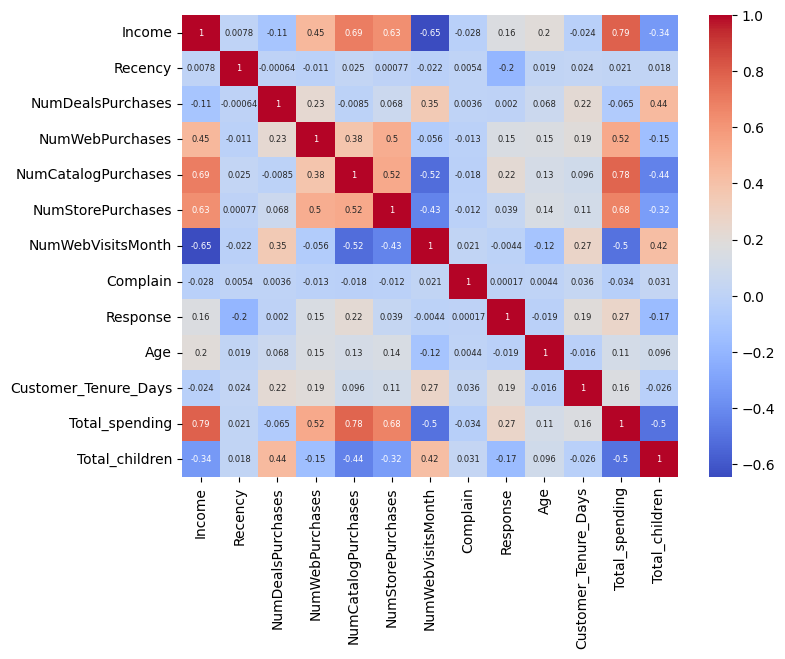

In [49]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 6},
    cmap="coolwarm"
)

In [50]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


Encoding

In [51]:
from sklearn.preprocessing import OneHotEncoder

In [52]:
ohe = OneHotEncoder()

cat_cols = ["Education","Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [53]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [54]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [55]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0



Scalling

In [59]:
from sklearn.preprocessing import StandardScaler

In [60]:
X = df_encoded

In [61]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Visualize

In [62]:
#2D 
from sklearn.decomposition import PCA

In [70]:
#pca = PCA(n_components=2) #for 2D
pca = PCA(n_components=3) #for 3D

X_pca = pca.fit_transform(X_scaled)

In [71]:
pca.explained_variance_ratio_  #ratio for 3D which is better than 2D

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3D projection')

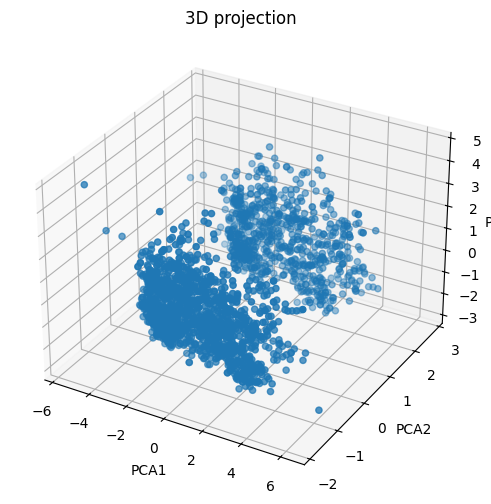

In [76]:
#plot for 2D
#plt.scatter(X_pca[:,0],X_pca[:,1]) 

#plot for 3D
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D projection")



In [68]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454])

Analyze Kvalue
1.Elbow method

In [89]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss =[]
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

knee = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k = knee.elbow

best k value =  4


Text(0, 0.5, 'wcss')

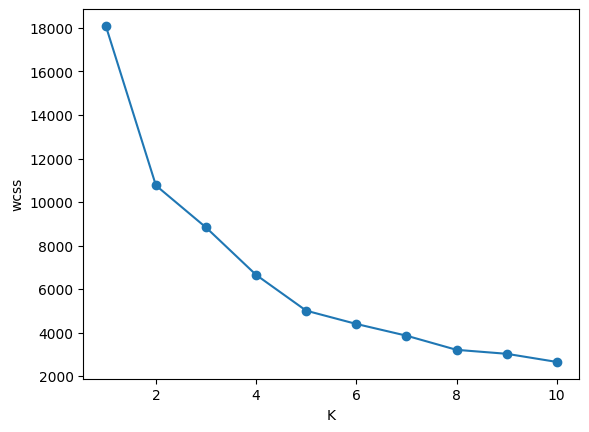

In [93]:
print("best k value = ",optimal_k)
#plot 
plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("K")
plt.ylabel("wcss")

2.silhoutte score

Text(0, 0.5, 'silhouette score')

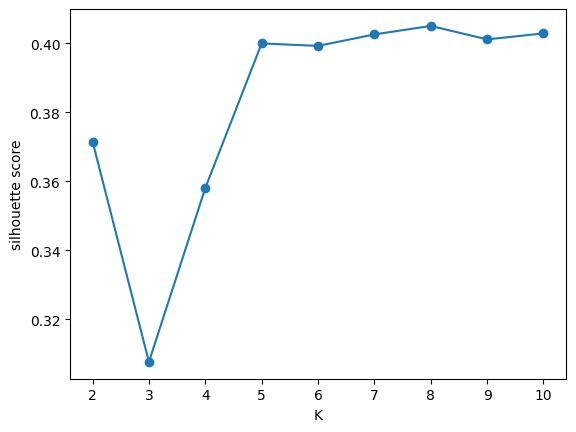

In [100]:
from sklearn.metrics import silhouette_score
scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca,labels)
    scores.append(score)

#plot 
plt.plot(range(2,11),scores,marker="o")
plt.xlabel("K")
plt.ylabel("silhouette score")

Text(0, 0.5, 'silhouette_score')

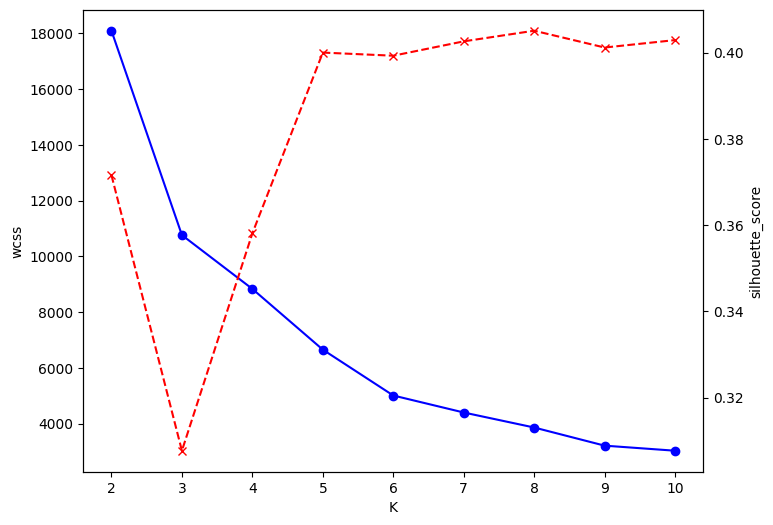

In [102]:
#combined plot 
k_range = range(2,11)
fig, ax1 = plt.subplots(figsize=(8,6))

ax1.plot(k_range,wcss[:len(k_range)],marker="o",color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("wcss")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)],marker="x",color="red",linestyle="--")
ax2.set_ylabel("silhouette_score")

#Clustering

In [104]:
#Kmeans 
kmeans = KMeans(n_clusters=4,random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

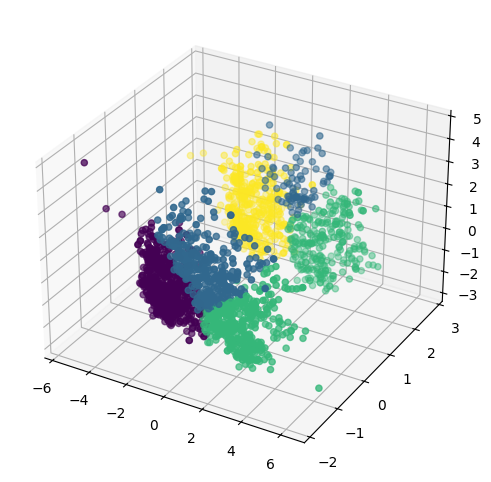

In [105]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c = labels_kmeans)

In [106]:
#Agglomerative clustering
from sklearn.cluster import AgglomerativeClustering

In [107]:
agg_clf = AgglomerativeClustering(n_clusters = 4, linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)

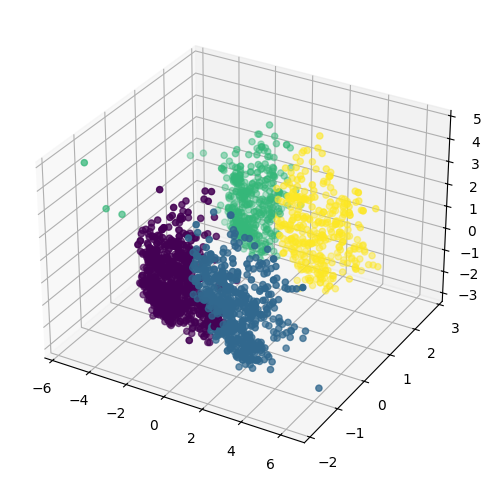

In [109]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c = labels_agg)

Characterization of Clusters

In [122]:
X["cluster"] = labels_agg

In [123]:
X.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_children,Living_With,labels,cluster
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone,3,3
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone,2,2
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner,1,1
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner,0,0
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner,0,0


<Axes: xlabel='cluster', ylabel='count'>

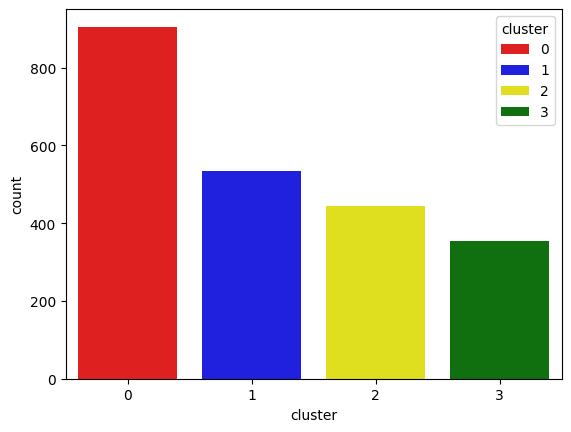

In [124]:
pal = ["red","blue","yellow","green"]

sns.countplot(x=X["cluster"],palette=pal, hue=X["cluster"])

<Axes: xlabel='Total_spending', ylabel='Income'>

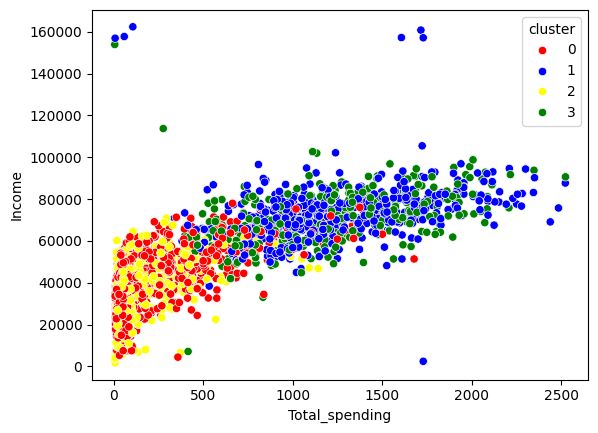

In [125]:
#Income and spending ptterns
sns.scatterplot(x=X["Total_spending"],y= X["Income"], hue=X["cluster"],palette=pal)

In [128]:
#cluster summary 
cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  Total_spending  \
cluster         